# Diabetes Risk Project: Data Cleaning & EDA

## Data Acquisition

This diabetes dataset has been acquired as a CSV file through UC Irvine's Machine Learning Repository, established by the Center of Disease Control (CDC). This dataset contains patient demographics, lab test results, and survey responses from patients in the US, used to determine which lifestyle factors serve as diabetes health indicators. There are 21 features, and the target variable is diabetes outcome: non-diabetic, pre-diabetic, or diabetic.

## Dataset Cleaning

Once acquiring the data, the next step is to clean the data. It's important to check for null values, duplicates, and outliers before analyzing and modeling the data, to prevent bias and inaccuracies downstream.

In [1]:
# Install necessary packages for dataset cleaning
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read csv file into dataframe
diabetes_df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
diabetes_df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [3]:
# Review the data types within the dataset
print(diabetes_df.dtypes)

# Indicate any missing/null values in the dataset
print(diabetes_df.isnull().sum())

# Indicate any duplicates in the dataset
print(diabetes_df.duplicated())

Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies               

In this dataset, all variables are represented as float values, so no type conversions are needed. Some values are categorical or binary, so it is important to indicate what the float values represent in visuals. There are no null values and duplicates in this dataset, so dropping rows is not needed.

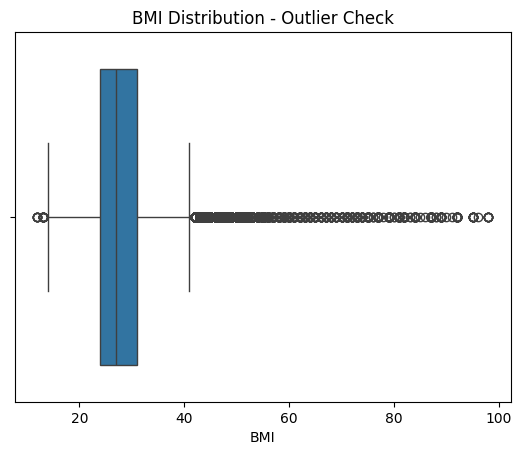

In [4]:
# Check for outliers in the dataset (most features are binary/ordinal categoricals)
sns.boxplot(x=diabetes_df['BMI'])
plt.title('BMI Distribution - Outlier Check')
plt.show()

## EDA

Now that the data has been observed and cleaned, the next step is for exploratory data analysis (EDA). Before developing a machine learning algorithm, it is important to note the correlation between lifestyle factors (features) and diabetes outcome (target variable). This helps determine which features to use for training, reducing model complexity and potential overfitting.

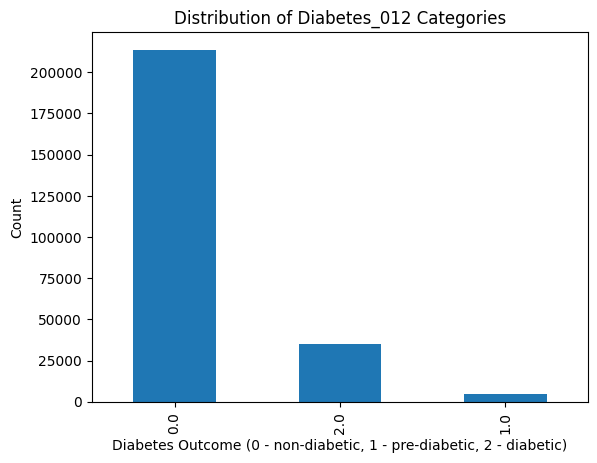

In [5]:
# Create a visualization demonstrating univariate patterns in the data
diabetes_df['Diabetes_012'].value_counts().plot(kind='bar')
plt.title('Distribution of Diabetes_012 Categories')
plt.xlabel('Diabetes Outcome (0 - non-diabetic, 1 - pre-diabetic, 2 - diabetic)')
plt.ylabel('Count')
plt.show()

In the bar graph, the majority of patients recorded in the dataset are not diabetic (0.0), over 200,000. About 40,000 patients are diabetic (2.0), and about 5,000 are pre-diabetic (1.0). This uneven distribution is important to note before modeling, since the minority classes (pre-diabetic and diabetic) won't be identified as accurately as the majority class (non-diabetic).

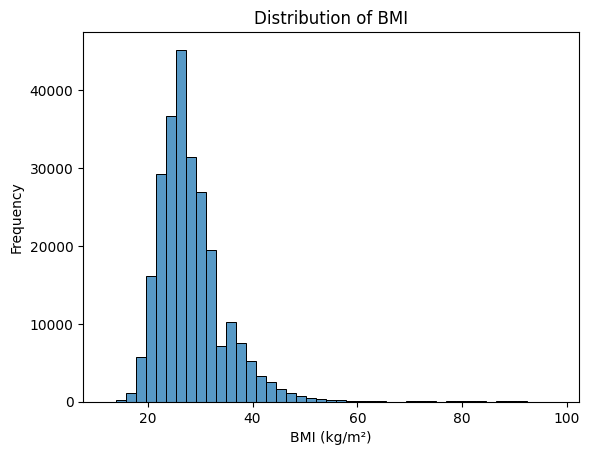

In [6]:
# Create a visualization demonstrating univariate patterns in the data
sns.histplot(diabetes_df['BMI'], bins=45)
plt.title('Distribution of BMI')
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Frequency')
plt.show()

This visual represents univariate patterns in the data through the distribution of BMIs in kg/m². The histogram is skewed right with a peak at the BMIs 24-26 kg/m².

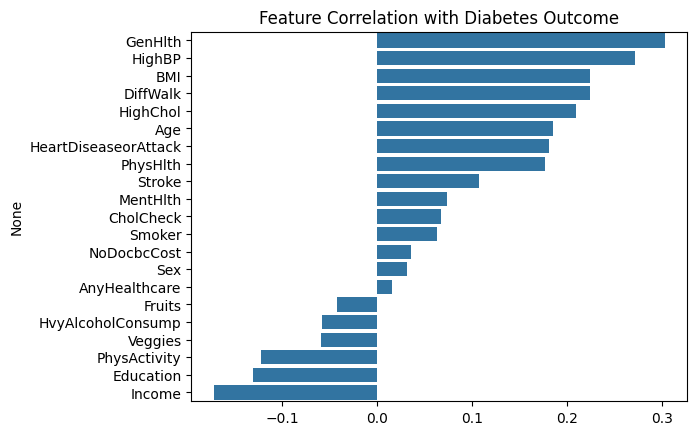

In [7]:
# Determine features that have top correlations with target for readability
corr_target = diabetes_df.corr()['Diabetes_012'].drop('Diabetes_012').sort_values(ascending=False)
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title('Feature Correlation with Diabetes Outcome')
plt.show()

Based on each feature's correlation with diabetes outcome, `HighBP`, `HighChol`, `BMI`, `HeartDiseaseorAttack`, `GenHlth`, `PhysHlth`, `DiffWalk`, and `Age` show the strongest correlation with the outcome. These features will be used for building a machine learning model in `02_model_engineering.ipynb`.

**Note:** cleaning did not remove or alter any rows (no nulls, no duplicates, BMI capping left commented out), so `02_model_engineering.ipynb` reads the same raw CSV directly rather than a cleaned intermediate file.